In [31]:
import numpy as np
import matplotlib.pyplot as plt


# ==================================================
# Signal functions
# ==================================================

def spatial_grid(L, Nx):
    return np.linspace(-L / 2, L / 2, Nx, endpoint=False)


def gaussian_thickness_profile(x, d0, h, sigma, x0=0):
    return d0 + h * np.exp(-((x - x0) ** 2) / (2 * sigma ** 2))


def phase_signal(d, n, lam):
    k = 2 * np.pi / lam
    return n * k * d


def phi_from_f(f):
    alpha = np.sum(f)

    phi = np.sqrt(f / alpha)

    phi = np.asarray(phi, dtype=complex)
    phi = phi / np.linalg.norm(phi)

    return phi, alpha


def plot_signal(x, f, n_qubits):
    plt.figure(figsize=(7, 4))

    plt.plot(x * 1e6, f)

    plt.xlabel("x (µm)")
    plt.ylabel("f(x) = n k d(x) (rad)")
    plt.title(f"Gaussian Phase Signal ({n_qubits} qubits)")

    plt.grid(True)
    plt.tight_layout()
    plt.show()

n_qubits: 7
Nx: 128
alpha: 63.998377844180254
psi shape: (128,)
psi norm: 1.0
min psi: 0.00034080790711798635
max psi: 0.17654286663549423


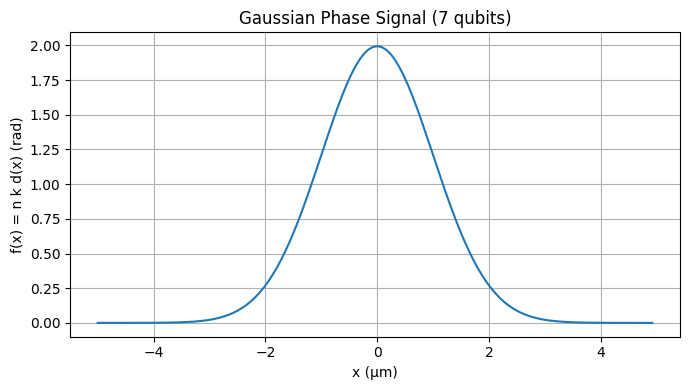

In [32]:
# ==================================================
# Parameters
# ==================================================

T = 10e-6

lam = 630e-9
n_refr = 1.0

d0 = 0.0
h = 200e-9
sigma = 1e-6
x0 = 0.0
number_of_layers =2

# ==================================================
# Build psi for one chosen qubit number
# ==================================================

n_qubits = 7
Nx = 2 ** n_qubits

print("n_qubits:", n_qubits)
print("Nx:", Nx)

x = spatial_grid(T, Nx)

d = gaussian_thickness_profile(
    x=x,
    d0=d0,
    h=h,
    sigma=sigma,
    x0=x0
)

f = phase_signal(
    d=d,
    n=n_refr,
    lam=lam
)

psi, alpha = phi_from_f(f)

print("alpha:", alpha)
print("psi shape:", psi.shape)
print("psi norm:", np.linalg.norm(psi))
print("min psi:", np.min(np.abs(psi)))
print("max psi:", np.max(np.abs(psi)))

plot_signal(x, f, n_qubits)

In [33]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit.quantum_info import Statevector

# This import depends on your old MPS initializer package.
# Use the same import you used before for QuantumState.
# Example:
# from qiskit_mps_initializer import QuantumState


# ==================================================
# Bond dimension functions
# ==================================================

def bond_dimension_at_cut(state, n_qubits, cut, tol=1e-12):
    """
    Compute exact Schmidt rank across one cut.
    """

    state = np.asarray(state, dtype=complex)

    matrix = state.reshape(
        2 ** cut,
        2 ** (n_qubits - cut)
    )

    singular_values = np.linalg.svd(matrix, compute_uv=False)

    rank = np.sum(singular_values > tol)

    return rank, singular_values


def max_bond_dimension(state, n_qubits, tol=1e-12):
    """
    Compute max bond dimension over all cuts.
    """

    ranks = []
    all_singular_values = []

    for cut in range(1, n_qubits):

        rank, singular_values = bond_dimension_at_cut(
            state=state,
            n_qubits=n_qubits,
            cut=cut,
            tol=tol
        )

        ranks.append(rank)
        all_singular_values.append(singular_values)

    max_D = max(ranks)

    return max_D, ranks, all_singular_values

In [34]:
from qiskit_mps_initializer.datatypes import QuantumState

# ==================================================
# Prepare psi
# ==================================================

psi = np.asarray(psi, dtype=complex)
psi = psi / np.linalg.norm(psi)

n_qubits = int(np.log2(len(psi)))

target_state = Statevector(psi)

print("n_qubits:", n_qubits)
print("len(psi):", len(psi))
print("norm psi:", np.linalg.norm(psi))


# ==================================================
# Scan over MPS initializer layers
# ==================================================

layer_list = range(1, 11)   # change this if you want more layers

max_bond_results = []
rank_profile_results = []

for number_of_layers in layer_list:

    print("\n" + "=" * 70)
    print("number_of_layers =", number_of_layers)
    print("=" * 70)

    # ----------------------------------------------
    # Build MPS initializer circuit for this layer number
    # ----------------------------------------------
    psi_state = QuantumState.from_dense_data(
        data=psi,
        normalize=True
    )

    U_psi = psi_state.generate_mps_initializer_circuit(
        number_of_layers=number_of_layers
    )

    # ----------------------------------------------
    # Take dagger
    # ----------------------------------------------
    U_psi_dagger = U_psi.inverse()

    # ----------------------------------------------
    # Apply U dagger to target state
    # This gives the new state chi_L
    # ----------------------------------------------
    chi_state = target_state.evolve(U_psi_dagger)

    chi = chi_state.data

    # ----------------------------------------------
    # Measure bond dimension of chi_L
    # ----------------------------------------------
    max_D, rank_profile, singular_values = max_bond_dimension(
        state=chi,
        n_qubits=n_qubits,
        tol=1e-12
    )

    max_bond_results.append(max_D)
    rank_profile_results.append(rank_profile)

    print("Max bond dimension after U_dagger:", max_D)
    print("Rank profile:", rank_profile)
    print("Circuit depth:", U_psi.depth())
    print("Circuit size:", U_psi.size())

n_qubits: 7
len(psi): 128
norm psi: 1.0

number_of_layers = 1
Max bond dimension after U_dagger: 8
Rank profile: [np.int64(2), np.int64(4), np.int64(8), np.int64(8), np.int64(4), np.int64(2)]
Circuit depth: 9
Circuit size: 14

number_of_layers = 2
Max bond dimension after U_dagger: 8
Rank profile: [np.int64(2), np.int64(4), np.int64(8), np.int64(8), np.int64(4), np.int64(2)]
Circuit depth: 11
Circuit size: 21

number_of_layers = 3
Max bond dimension after U_dagger: 8
Rank profile: [np.int64(2), np.int64(4), np.int64(8), np.int64(8), np.int64(4), np.int64(2)]
Circuit depth: 13
Circuit size: 28

number_of_layers = 4
Max bond dimension after U_dagger: 8
Rank profile: [np.int64(2), np.int64(4), np.int64(8), np.int64(8), np.int64(4), np.int64(2)]
Circuit depth: 15
Circuit size: 35

number_of_layers = 5
Max bond dimension after U_dagger: 8
Rank profile: [np.int64(2), np.int64(4), np.int64(8), np.int64(8), np.int64(4), np.int64(2)]
Circuit depth: 17
Circuit size: 42

number_of_layers = 6
Max 

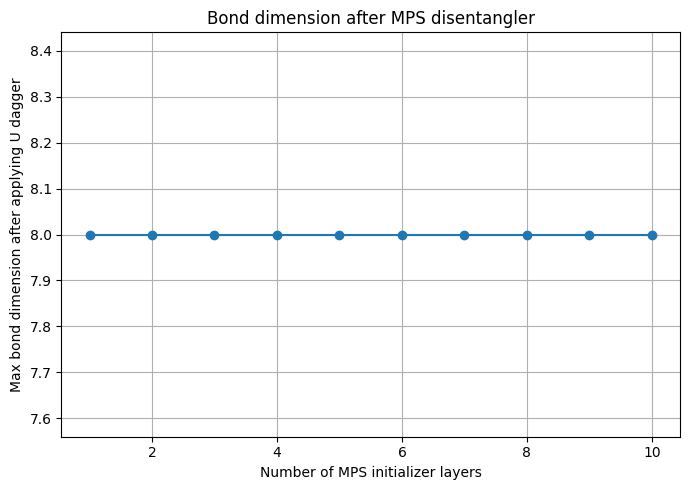

In [35]:
plt.figure(figsize=(7, 5))

plt.plot(
    list(layer_list),
    max_bond_results,
    marker="o"
)

plt.xlabel("Number of MPS initializer layers")
plt.ylabel("Max bond dimension after applying U dagger")
plt.title("Bond dimension after MPS disentangler")

plt.grid(True)
plt.tight_layout()
plt.show()

In [36]:
print("\nSummary")
print("layers | max bond dimension | rank profile")

for L, D, profile in zip(layer_list, max_bond_results, rank_profile_results):
    print(f"{L:6d} | {D:18d} | {profile}")


Summary
layers | max bond dimension | rank profile
     1 |                  8 | [np.int64(2), np.int64(4), np.int64(8), np.int64(8), np.int64(4), np.int64(2)]
     2 |                  8 | [np.int64(2), np.int64(4), np.int64(8), np.int64(8), np.int64(4), np.int64(2)]
     3 |                  8 | [np.int64(2), np.int64(4), np.int64(8), np.int64(8), np.int64(4), np.int64(2)]
     4 |                  8 | [np.int64(2), np.int64(4), np.int64(8), np.int64(8), np.int64(4), np.int64(2)]
     5 |                  8 | [np.int64(2), np.int64(4), np.int64(8), np.int64(8), np.int64(4), np.int64(2)]
     6 |                  8 | [np.int64(2), np.int64(4), np.int64(8), np.int64(8), np.int64(4), np.int64(2)]
     7 |                  8 | [np.int64(2), np.int64(4), np.int64(8), np.int64(8), np.int64(4), np.int64(2)]
     8 |                  8 | [np.int64(2), np.int64(4), np.int64(8), np.int64(8), np.int64(4), np.int64(2)]
     9 |                  8 | [np.int64(2), np.int64(4), np.int64(8), np.int

In [37]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_mps_initializer.datatypes import QuantumState

psi = np.asarray(psi, dtype=complex)

psi = psi /np.linalg.norm(psi)

qc = QuantumCircuit(n_qubits)
qc.initialize(psi, range(n_qubits))

zero_state = Statevector.from_label('0'*n_qubits)
prepared_state = zero_state.evolve(qc)

fideality = np.abs(np.vdot(psi, prepared_state.data))**2

print('fideakity', fideality)

fideakity 1.0


In [38]:
psi_state = QuantumState.from_dense_data(data=psi, normalize=True)

U_psi =psi_state.generate_mps_initializer_circuit(number_of_layers=number_of_layers)

U_psi_dagger = U_psi.inverse()